In [2]:
pip install google-play-scraper Sastrawi wordcloud matplotlib scikit-learn pandas

In [3]:
import pandas as pd
from google_play_scraper import Sort, reviews

# ambil data Shopee
result, _ = reviews(
    'com.shopee.id',
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=1000
)

df = pd.DataFrame(result)

# ambil kolom penting saja
df_sentimen = df[['userName', 'score', 'at', 'content']]

# simpan data mentah
df_sentimen.to_csv('ulasan_shopee_mentah.csv', index=False, encoding='utf-8')

print(f"Selesai! Data {len(df_sentimen)} berhasil diambil")

Selesai! Data 1000 berhasil diambil


In [4]:
import pandas as pd
import re
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# load data
df = pd.read_csv('ulasan_shopee_mentah.csv')

# hapus data kosong & duplikat
df = df.dropna()
df = df.drop_duplicates()

# label sentiment (FIXED)
df['label'] = df['score'].apply(lambda x: 1 if x > 3 else 0)

In [5]:
kamus_gaul = {
    "jg": "juga",
    "yg": "yang",
    "bgt": "banget",
    "gk": "tidak",
    "ga": "tidak",
    "lemot": "lambat"
}

def normalisasi_kata(teks):
    kata_kata = teks.split()
    kata_normal = [kamus_gaul[kata] if kata in kamus_gaul else kata for kata in kata_kata]
    return " ".join(kata_normal)

In [6]:
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

def bersihkan_teks(teks):
    teks = str(teks).lower()

    # hapus angka & simbol
    teks = re.sub(r'[^a-zA-Z\s]', '', teks)

    # normalisasi kata gaul
    teks = normalisasi_kata(teks)

    # hapus stopword
    teks = stopword_remover.remove(teks)

    return teks.strip()


# apply preprocessing
df['clean_content'] = df['content'].apply(bersihkan_teks)

# hapus data kosong hasil cleaning
df = df[df['clean_content'] != ""]

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=1000)

X = tfidf.fit_transform(df['clean_content'])
y = df['label']

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [9]:
from sklearn.svm import SVC

model_svm = SVC(kernel='linear')
model_svm.fit(X_train, y_train)

SVC(kernel='linear')

In [10]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model_svm.predict(X_test)

print("Akurasi:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=['Negatif','Positif']))

Akurasi: 0.9030612244897959
              precision    recall  f1-score   support

     Negatif       0.89      0.92      0.91        99
     Positif       0.91      0.89      0.90        97

    accuracy                           0.90       196
   macro avg       0.90      0.90      0.90       196
weighted avg       0.90      0.90      0.90       196



In [13]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

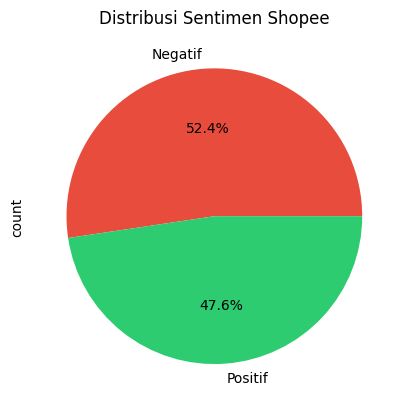

In [14]:
df['label'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['Negatif', 'Positif'],
    colors=['#e74c3c', '#2ecc71']
)

plt.title("Distribusi Sentimen Shopee")
plt.show()

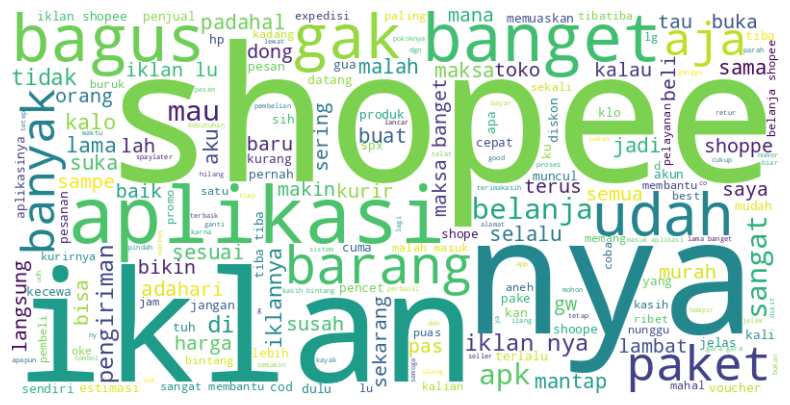

In [15]:
semua_teks = " ".join(df['clean_content'].astype(str))

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(semua_teks)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [22]:
import joblib

joblib.dump(model_svm, "svm_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model berhasil disimpan!")

Model berhasil disimpan!


In [23]:
import os
os.listdir()

['.config',
 'tfidf_vectorizer.pkl',
 'ulasan_shopee_mentah.csv',
 'svm_model.pkl',
 'sample_data']

In [24]:
from google.colab import files

files.download("svm_model.pkl")
files.download("tfidf_vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

files.download("ulasan_shopee_mentah.csv")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [25]:
import sklearn
import joblib

print("sklearn:", sklearn.__version__)

sklearn: 1.6.1


In [16]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [20]:
df = pd.read_csv("ulasan_shopee_mentah.csv")

df.head()

,userName,score,at,content
0,Yan Kasera,5,2026-07-05 10:50:39,blanja pake sopy nyaman dan terlindungi
1,Eny Pujiastutik,1,2026-07-05 10:49:11,"balsis gak karu2an, kalo gak niat kasih voc me..."
2,Samir,5,2026-07-05 10:49:04,mantap
3,Adinda Bilqis,1,2026-07-05 10:48:56,"kalo bikin iklan jangan bikin orang pusing,aku..."
4,Rifky Fadhlan,5,2026-07-05 10:47:34,Barang yang dipesan selalu sesuai yg diinginkan.


In [21]:
teks = ["barang sangat bagus dan cepat sampai"]

vektor = tfidf.transform(teks)

prediksi = model_svm.predict(vektor)

print(prediksi)

[1]
